In [1]:
from toolbox.cSection import makeSampleCrossSection
from toolbox.patterns import Patterns
from toolbox.periodic import PeriodicTissue
from toolbox import stress
import matplotlib.pyplot as plt
from toolbox import stress
import os
import numpy as np
# test_sample = "7_bidisperse_5_5.2/"
test_sample = "7_bidisperse_5_4.9/"
# 
if os.path.isdir(test_sample):
    os.system("rm -r {}".format(test_sample))
os.system("cp -r init/{} {}".format(test_sample,test_sample))
dir = test_sample
file = "minimized.txt"

alpha = 0.009
tissue = PeriodicTissue.from_config(dir,file)
training_instance = Patterns.periodic_tissue(tissue)
training_instance.set_tolerance(1e-6)
training_instance.set_random_target_cells()
# training_instance.set_central_target_cells()

for cellID in training_instance._target_cell_to_stress:
    initial_stress = stress.calculate_max_shear_stress(training_instance._config, cellID)
    training_instance._target_cell_to_stress[cellID] = (1+alpha) * initial_stress
    # training_instance._target_cell_to_stress[cellID] = alpha
    print("Initial stress for cell {}: {}".format(cellID, initial_stress))
print(training_instance._target_cell_to_stress)
training_instance.run()



Initial stress for cell 126: 0.12247351323591471
{126: 0.12357577485503793}
Initial Cost: 1.21e-06




Starting iteration: 0




Number of modifiable cells: 343


-------------------------------------
Step 1: Evaluate and store the current (free state) areas of hidden (non-target) cells


-------------------------------------
Step 2: CLAMPING
Clamping iteration 0
Cell: 126, Final Target Stress: 0.12357577485503793 Temporary Target Stress: 0.12493790319179912, Current stress: 0.12247351323591471, s0: 5.0
Initialization start ...
Number of vertices: 2040
Maximum vertex ID: 6096
Number of edges: 4080
Maximum edge ID: 16897
Number of polygons: 2383
Maximum polygon ID: 3303
Number of cells: 343
Maximum cell ID: 342
Number of polygons with two neighboring cells: 2383/2383
time: 0 ~ 2000 ~ 0.005 ~ 0.05
dump: vtk 100
log: 100
Average s0: 5
Lth: 0.02 verbose: 0
temperature: 0.0001
kv: 1
box: 7 7 7 periodic boundary condition: 1 1 1


Initial F_rms: 0.0661775

Starting FIRE minimization...
Real 

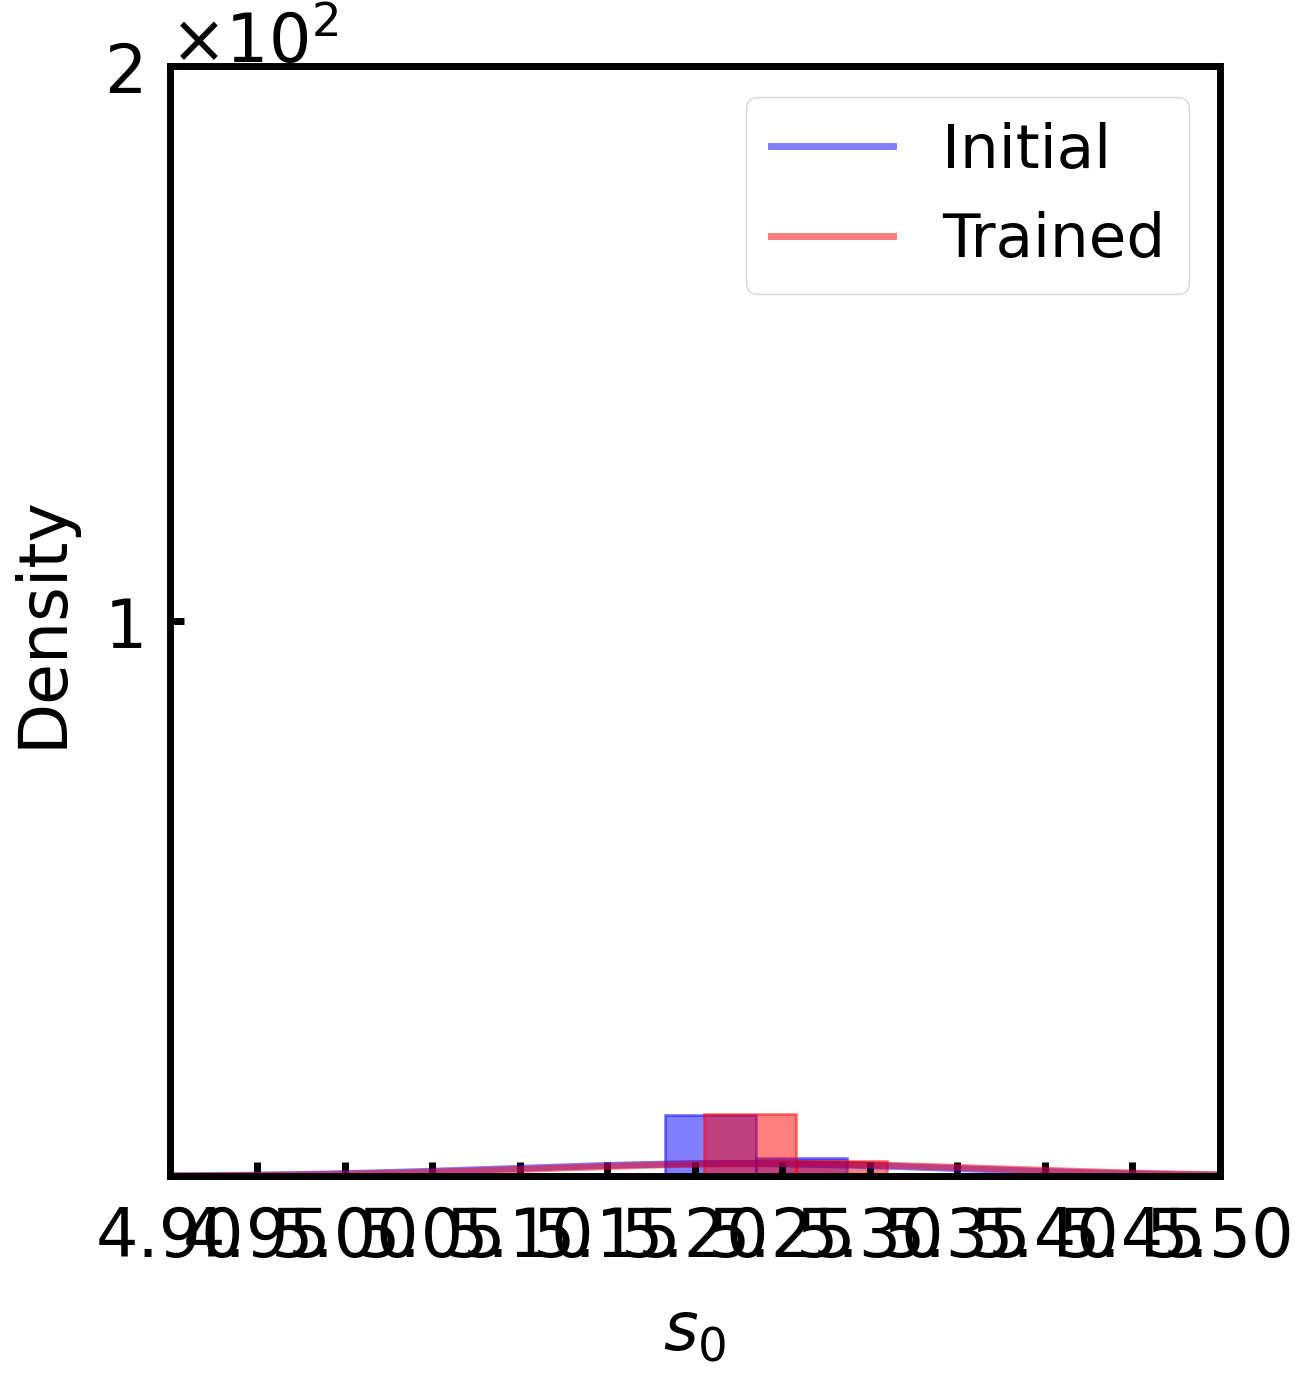

In [5]:
import pandas as pd
from toolbox import manuscriptPlots

dir = "7_bidisperse_5_4.9/"
df = pd.read_csv("{}cellParameters.0.input".format(dir), sep=" ",header=None)
final = 4
iter_to_labels = {0:"Initial", final:"Trained"}
iter_to_colors = {0:"blue", final:"red"}
plotter = manuscriptPlots.plot()
plotter.set_ylim(0,200)
plotter.set_xlim(4.9,5.5)
# plotter.set_title(" p = {:.2f}".format(p))
plotter.set_xlabel(r"$s_0$")
plotter.set_xticks([4.9+0.05*i for i in range(50)])
plotter.set_yticks([100*i for i in range(1,100)])
plotter.set_yScaled()
plotter.initialize_figure()
for i, label in iter_to_labels.items():
    df = pd.read_csv("{}cellParameters.{}.input".format(dir,i), sep=" ",header=None)


    plotter.histogram_from_dataframe(df[2],color=iter_to_colors[i], bins=20, label = label)
plotter.save_fig("{}s0_histogram.jpg".format(dir))
